# Introducción

Este proyecto tiene como objetivo analizar un dataset de productos de e-commerce (Amazon), el cual presenta múltiples desafíos típicos de datos reales, como inconsistencias, valores faltantes y estructuras no normalizadas.

Durante el proceso inicial se detectaron problemas en la carga y transformación de los datos, particularmente en variables clave como precios y conteo de valoraciones, que resultaban en valores nulos debido a la presencia de caracteres especiales y formatos no estandarizados.

A partir de este diagnóstico, se implementó un proceso de limpieza más robusto, eliminando símbolos, espacios invisibles y texto no numérico para recuperar correctamente la información.

Posteriormente, el dataset fue normalizado en múltiples tablas relacionales y analizado mediante SQL y Python, con el objetivo de extraer insights relevantes sobre productos, precios, descuentos y comportamiento de usuarios.

Este proyecto refleja un flujo completo de trabajo en análisis de datos, desde la detección de errores en el pipeline hasta la generación de visualizaciones e interpretación de resultados.

# Objetivos del proyecto

## Objetivo general

Transformar un dataset crudo en un modelo estructurado y confiable, y analizar patrones relevantes en productos y comportamiento de usuarios.

## Objetivos específicos

* Identificar y corregir errores en la carga y transformación de datos
* Limpiar variables con caracteres especiales y formatos inconsistentes
* Convertir datos textuales a formatos numéricos utilizables
* Normalizar el dataset en tablas relacionales (products, users, reviews)
* Analizar la relación entre precios, descuentos y ratings
* Identificar patrones en la actividad de usuarios
* Generar visualizaciones para comunicar insights de negocio

In [ ]:
# Import necessary libraries
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Connect to the SQL Server database
conn = pyodbc.connect(
    r"DRIVER={SQL Server};"
    r"SERVER=APWASSERMAN\SQLEXPRESS;"
    r"DATABASE=Amazon;"
    r"Trusted_Connection=yes;"
)

In [4]:
# Execute a SQL query to retrieve data from the 'products' table
query = "SELECT * FROM products"

df_products = pd.read_sql(query, conn)

C:\Users\PAMELA\AppData\Local\Temp\ipykernel_18280\4267229505.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(query, conn)


In [5]:
df_products.head()

,product_id,product_name,category,actual_price,discounted_price,discount_percentage,rating,rating_count
0,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adap...,Computers&Accessories|NetworkingDevices|Networ...,1208.0,507.0,58.0,4.1,8131.0
1,B002SZEOLG,TP-Link Nano USB WiFi Dongle 150Mbps High Gain...,Computers&Accessories|NetworkingDevices|Networ...,1339.0,749.0,44.0,4.2,179692.0
2,B003B00484,Duracell Plus AAA Rechargeable Batteries (750 ...,Electronics|GeneralPurposeBatteries&BatteryCha...,499.0,399.0,20.0,4.3,27201.0
3,B003L62T7W,"Logitech B100 Wired USB Mouse, 3 yr Warranty, ...",Computers&Accessories|Accessories&Peripherals|...,375.0,279.0,26.0,4.3,31534.0
4,B004IO5BMQ,"Logitech M235 Wireless Mouse, 1000 DPI Optical...",Computers&Accessories|Accessories&Peripherals|...,995.0,699.0,30.0,4.5,54405.0


In [6]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1351 non-null   object 
 1   product_name         1351 non-null   object 
 2   category             1351 non-null   object 
 3   actual_price         1351 non-null   float64
 4   discounted_price     1351 non-null   float64
 5   discount_percentage  1351 non-null   float64
 6   rating               1350 non-null   float64
 7   rating_count         1349 non-null   float64
dtypes: float64(5), object(3)
memory usage: 84.6+ KB


In [7]:
df_products.shape

(1351, 8)

In [8]:
df_products.describe()

,actual_price,discounted_price,discount_percentage,rating,rating_count
count,1351.000000,1351.000000,1351.000000,1350.000000,1349.000000
mean,5690.510452,3304.653716,46.679497,4.091852,17644.524092
std,11218.918302,7174.004484,21.621495,0.297444,42145.655622
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,899.000000,349.000000,31.000000,3.900000,1106.000000
50%,1790.000000,899.000000,49.000000,4.100000,4740.000000
75%,4575.000000,2174.000000,62.000000,4.300000,16020.000000
max,139900.000000,77990.000000,94.000000,5.000000,426973.000000


In [ ]:
# Check for missing values
df_products['rating'] = df_products['rating'].fillna(df_products['rating'].mean())
df_products['rating_count'] = df_products['rating_count'].fillna(df_products['rating_count'].mean())

In [ ]:
# Verify that there are no more missing values
df_products.isnull().sum()

product_id             0
product_name           0
category               0
actual_price           0
discounted_price       0
discount_percentage    0
rating                 0
rating_count           0
dtype: int64

# Graficos

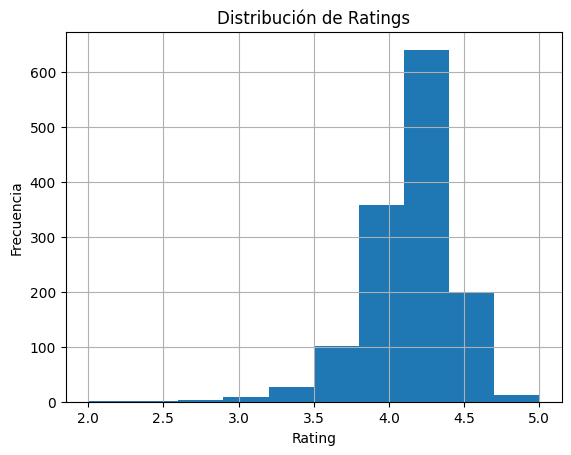

In [11]:
# Visualize the distribution of ratings
plt.figure()
df_products['rating'].dropna().hist()
plt.title("Distribución de Ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

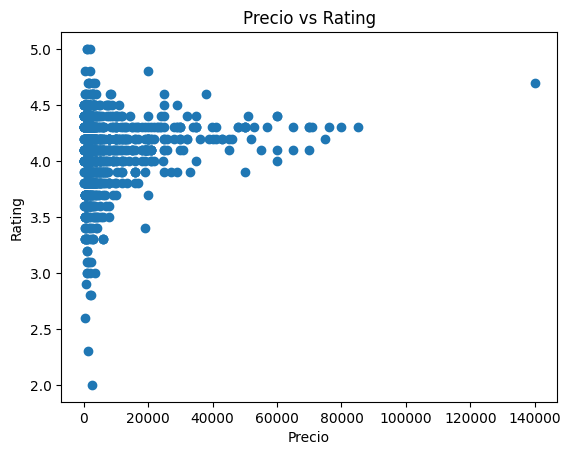

In [12]:
# Visualize the relationship between price and rating
plt.figure()
plt.scatter(df_products['actual_price'], df_products['rating'])
plt.title("Precio vs Rating")
plt.xlabel("Precio")
plt.ylabel("Rating")
plt.show()

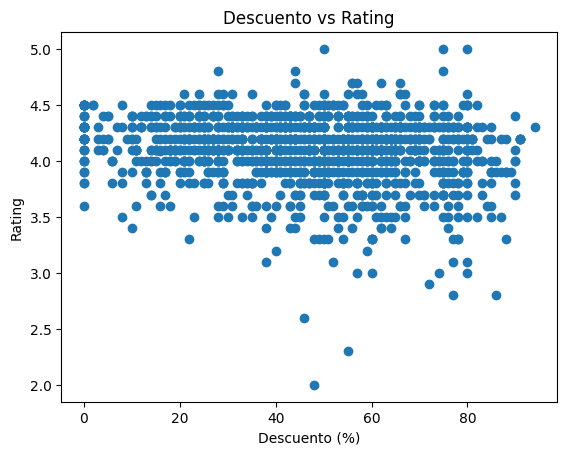

In [13]:
# Visualize the relationship between discount percentage and rating
plt.figure()
plt.scatter(df_products['discount_percentage'], df_products['rating'])
plt.title("Descuento vs Rating")
plt.xlabel("Descuento (%)")
plt.ylabel("Rating")
plt.show()

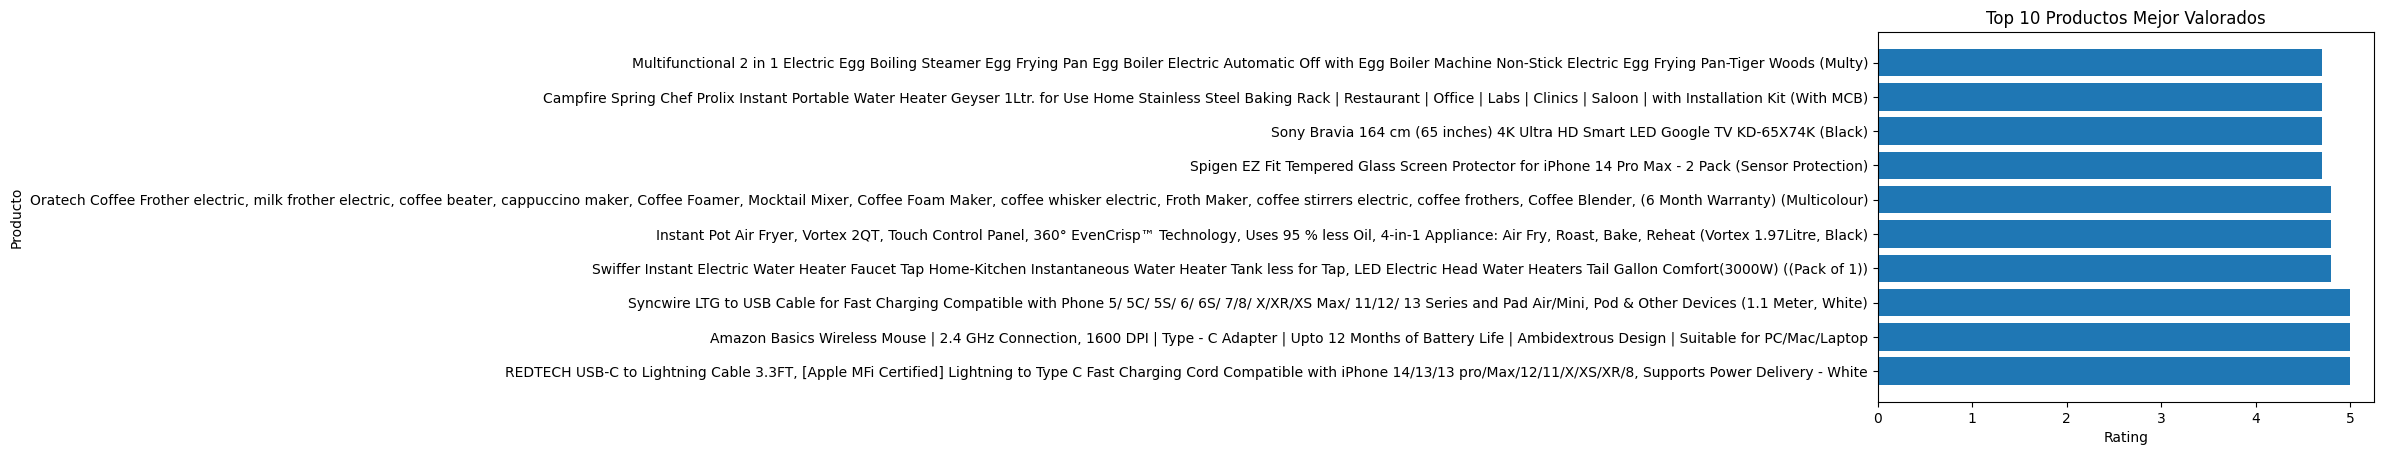

In [14]:
# Identify top 10 products based on rating and rating count
top_products = df_products.sort_values(
    by=['rating', 'rating_count'], 
    ascending=False
).head(10)

# Visualize the top 10 products
plt.figure()
plt.barh(top_products['product_name'], top_products['rating'])
plt.title("Top 10 Productos Mejor Valorados")
plt.xlabel("Rating")
plt.ylabel("Producto")
plt.show()

In [15]:
# Execute a SQL query to retrieve data from the 'reviews' table
query = """
SELECT user_id, COUNT(*) as total_reviews
FROM reviews
GROUP BY user_id
"""

df_users = pd.read_sql(query, conn)

C:\Users\PAMELA\AppData\Local\Temp\ipykernel_18280\1960344371.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql(query, conn)


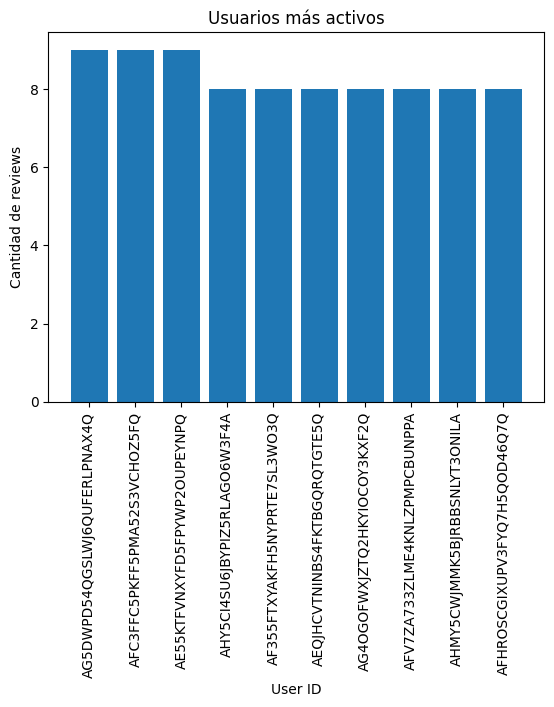

In [16]:
# Visualize the top 10 most active users based on total reviews
top_users = df_users.sort_values(by='total_reviews', ascending=False).head(10)

plt.figure()
plt.bar(top_users['user_id'], top_users['total_reviews'])
plt.title("Usuarios más activos")
plt.xlabel("User ID")
plt.ylabel("Cantidad de reviews")
plt.xticks(rotation=90)
plt.show()

In [17]:
# Create a new column to categorize products based on price
def rango_precio(x):
    if x < 1000:
        return "Barato"
    elif x < 5000:
        return "Medio"
    else:
        return "Caro"

df_products['price_range'] = df_products['actual_price'].apply(rango_precio)

In [18]:
# Calculate the average rating for each price range
avg_rating = df_products.groupby('price_range')['rating'].mean()

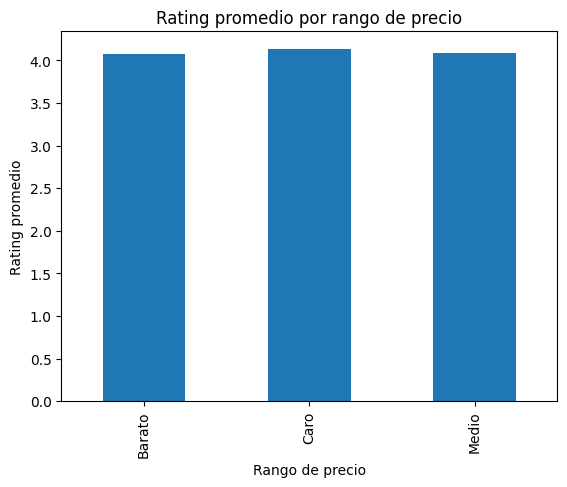

In [19]:
# Visualize the average rating for each price range
plt.figure()
avg_rating.plot(kind='bar')
plt.title("Rating promedio por rango de precio")
plt.xlabel("Rango de precio")
plt.ylabel("Rating promedio")
plt.show()

# Conclusiones

El proyecto permitió transformar un dataset inicialmente inconsistente en una fuente de información confiable para el análisis.

Uno de los principales desafíos fue la pérdida de datos en variables clave como precios, causada por la presencia de caracteres especiales e invisibles que impedían su correcta conversión. Este problema fue resuelto mediante la implementación de una estrategia de limpieza más robusta, lo que permitió recuperar información crítica para el análisis.

A partir del dataset limpio y estructurado, se identificaron los siguientes insights:

* No existe una relación directa entre precio y rating, lo que sugiere que productos más costosos no necesariamente tienen mejor valoración
* Los descuentos elevados no garantizan mejores calificaciones por parte de los usuarios
* Un grupo reducido de usuarios concentra una gran cantidad de reviews, evidenciando patrones de alta actividad
* La calidad y estructura de los datos impactan directamente en el tipo de análisis que se puede realizar

Además, el proyecto permitió aplicar y consolidar conceptos clave como:

* Limpieza avanzada de datos
* Normalización de bases de datos
* Uso de funciones avanzadas en SQL (STRING_SPLIT, ROW_NUMBER)
* Integración entre SQL y Python
* Visualización de datos para la toma de decisiones

En conjunto, este trabajo demuestra la importancia de un enfoque integral en análisis de datos, donde la comprensión y preparación de los datos es tan relevante como el análisis en sí.